In [ ]:
%reset -f
import torch
import torch.nn as nn #Modulo para construção de redes neurais 
import torch.optim as optim #Modulo para implementar os algoritmos de otimização
from torch.utils.data import TensorDataset, DataLoader #Funções para manipulação dos dados 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split #Algoritmos para pré-processamento de dados, compararação de modelos, validação, ...

#Set default dtype to float32
torch.set_default_dtype(torch.float)

#PyTorch random number generator
torch.manual_seed(1234)

# Random number generators in other libraries
np.random.seed(1234)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("device: ",device)

if device == 'cuda': 
    print(torch.cuda.get_device_name())
    


# Função Real / Solução Analítica
def fx(x):
    return np.sin(np.pi*x)

#Função Residual da Equação diferencial
def PDE(x):
    return -1*(np.pi**2)*torch.sin(np.pi*x)

#Função para satisfazer condição de contorno
def BC(x):
    return 1-torch.abs(x)




#Rede Neural
class NN(nn.Module):
    #Inicialização
    def __init__(self,layers):
        super(NN,self).__init__()
        self.LossFcn = nn.MSELoss() #Definir a função custo
        self.activation = nn.Tanh() #Função de Ativação tangente hiperbólica
        self.linears = nn.ModuleList([nn.Linear(layers[i], layers[i+1]) for i in range(len(layers)-1)])
        
    
    #Feed Forward
    def forward(self,x):               
        for i in range(len(layers)-2):  
            x = self.linears[i](x)              
            x = self.activation(x)    
        x = self.linears[-1](x)
        return x
    
    #Funções de perda
    
    #Função de Perda PDE
    def loss_PDE(self,x_PDE):
        g = x_PDE.clone()
        g.requires_grad = True
        u = self.forward(g)
        u_x = torch.autograd.grad(u,g,torch.ones([x_PDE.shape[0],1]).to(device),retain_graph=True,create_graph=True)[0] #Primeira derivada
        u_xx = torch.autograd.grad(u_x,g,torch.ones([x_PDE.shape[0],1]).to(device),create_graph=True)[0] #Segunda derivada
        return self.LossFcn(u_xx,PDE(g))    
    
    #Função de Perda da condição de contorno
    def loss_BC(self,x_BC,y_BC):
        return self.LossFcn(self.forward(x_BC),y_BC)
    
    #Função de Perda do conjunto de dados
    def loss(self,x_BC,y_BC,x_PDE):
        lossPDE = self.loss_PDE(x_PDE)
        lossBC = self.loss_BC(x_BC,y_BC)
        #lossData = self.LossFcn(Outputs,Targets)
        return lossPDE+lossBC
        
    

      

device:  cpu


## Total Loss Function

The total loss function of the PINN is defined as the sum of the PDE loss, boundary condition loss, and data loss:

$$
\mathcal{L}_{total}
=
\mathcal{L}_{PDE}
+
\mathcal{L}_{BC}
+
\mathcal{L}_{data}
$$

A weighted version can also be used:

$$
\mathcal{L}_{total}
=
\lambda_{PDE}\mathcal{L}_{PDE}
+
\lambda_{BC}\mathcal{L}_{BC}
+
\lambda_{data}\mathcal{L}_{data}
$$

where:
- $\lambda_{PDE}$ controls the importance of the PDE residual
- $\lambda_{BC}$ controls the importance of the boundary conditions
- $\lambda_{data}$ controls the importance of the training data

## Data Loss

Suppose we have training data points

$$
(x_i, y_i)
$$

where:
- $x_i$ are the input locations
- $y_i$ are the known solution values

The data loss is defined as the mean squared error between the neural network prediction and the known data:

$$
\mathcal{L}_{data}
=
\frac{1}{N_{data}}
\sum_{i=1}^{N_{data}}
\left(
u(x_i) - y_i
\right)^2
$$


## PDE Loss

For the PDE

$$
u''(x) = -\pi^2 \sin(\pi x)
$$

the PINN PDE residual is

$$
u''(x) + \pi^2 \sin(\pi x)
$$

because we move everything to one side:

$$
u''(x) + \pi^2 \sin(\pi x) = 0
$$


The PDE loss is usually defined as the mean squared residual:

$$
\mathcal{L}_{PDE}
=
\frac{1}{N}
\sum_{i=1}^{N}
\left(
u''(x_i) + \pi^2 \sin(\pi x_i)
\right)^2
$$

## Boundary Condition Loss

Suppose the boundary conditions are

$$
u(-1) = 0
$$

and

$$
u(1) = 0
$$

The boundary condition loss is defined as the mean squared error at the boundary points:

$$
\mathcal{L}_{BC}
=
\frac{1}{N_{BC}}
\sum_{i=1}^{N_{BC}}
\left(
u(x_i^{BC}) - u_i^{BC}
\right)^2
$$

where:
- $x_i^{BC}$ are the boundary points
- $u_i^{BC}$ are the target boundary values

In [135]:
#Geração dos dados
x = np.linspace(-1,1,400)
y = fx(x)
#y = y +np.random.normal(0,0.5,y.shape)

x_BC, y_BC = torch.Tensor([-1,1]).float().view(-1,1), torch.Tensor([0,0]).float().view(-1,1)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.1, random_state=42, shuffle= True)
x_train, y_train = torch.Tensor(x_train).float(), torch.Tensor(y_train).float()
x_test, y_test = torch.Tensor(x_test).float(), torch.Tensor(y_test).float()




In [136]:

layers = np.array([1,10,1])
model = NN(layers)
optimizer = optim.SGD(model.parameters(),lr=0.01, momentum=0.9)
print(model)


NN(
  (LossFcn): MSELoss()
  (activation): Tanh()
  (linears): ModuleList(
    (0): Linear(in_features=1, out_features=10, bias=True)
    (1): Linear(in_features=10, out_features=1, bias=True)
  )
)


In [137]:
#Treinamento por Backpropagation
train_dataset = TensorDataset(x_train.view(-1,1),y_train.view(-1,1))
test_dataset = TensorDataset(x_test.view(-1,1),y_test.view(-1,1))

#Treinamento em Mini-batch.
train_loader = DataLoader(train_dataset, batch_size=360, shuffle=False)

num_epochs = 500
losses = [] #Vetor para salvar o comportamento da função custo
model.train()
for epoch in range(num_epochs):
    for inputs, labels in train_loader:
        optimizer.zero_grad() #Zera o gradiente
        #outputs = model(inputs) #Faz o Feedforward e encontra as predições da rede
        loss = model.loss(x_BC,y_BC,inputs)#Calcula o erro (Diferença entre a predição e a saída do dado)
        loss.backward() #Faz a retroprogação do erro e calcula o gradiente em relação a cada parâmetro do modelo
        optimizer.step() #Atualiza os parâmetros(Pesos e vieses) com base no gradiente e a taxa de aprendizado
        if epoch%(num_epochs/20)==0:
            print(loss)
    losses.append(loss.item())

model.eval()
test_loader = DataLoader(test_dataset, batch_size=40, shuffle=False)
with torch.no_grad(): # Disable gradient computation
    for inputs, labels in test_loader:
        outputs = model(inputs) #Faz o Feedforward e encontra as predições da rede
           

tensor(49.3730, grad_fn=<AddBackward0>)
tensor(5.3312, grad_fn=<AddBackward0>)
tensor(0.7545, grad_fn=<AddBackward0>)
tensor(0.3210, grad_fn=<AddBackward0>)
tensor(0.2031, grad_fn=<AddBackward0>)
tensor(0.1402, grad_fn=<AddBackward0>)
tensor(0.0909, grad_fn=<AddBackward0>)
tensor(0.0561, grad_fn=<AddBackward0>)
tensor(0.0343, grad_fn=<AddBackward0>)
tensor(0.0218, grad_fn=<AddBackward0>)
tensor(0.0146, grad_fn=<AddBackward0>)
tensor(0.0105, grad_fn=<AddBackward0>)
tensor(0.0079, grad_fn=<AddBackward0>)
tensor(0.0062, grad_fn=<AddBackward0>)
tensor(0.0050, grad_fn=<AddBackward0>)
tensor(0.0042, grad_fn=<AddBackward0>)
tensor(0.0036, grad_fn=<AddBackward0>)
tensor(0.0032, grad_fn=<AddBackward0>)
tensor(0.0029, grad_fn=<AddBackward0>)
tensor(0.0026, grad_fn=<AddBackward0>)


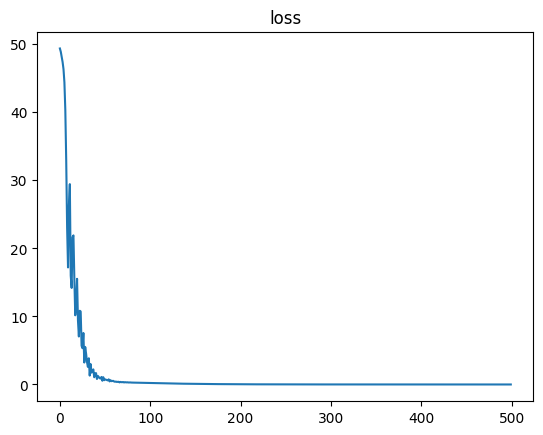

In [138]:
plt.title('loss')
plt.plot(losses)
plt.show()


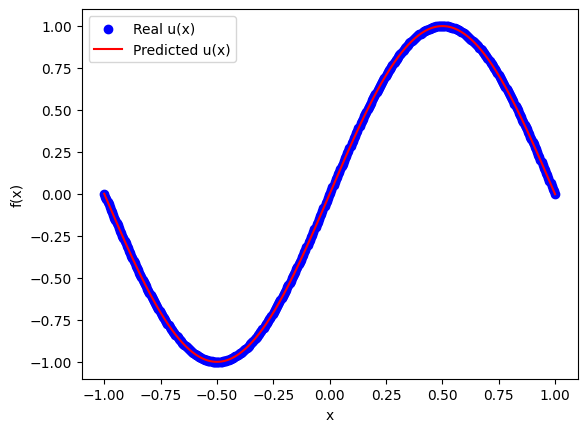

In [139]:
# Plot
fig, ax1 = plt.subplots()
ax1.scatter(x,y,color='blue',label='Real u(x)')
ax1.plot(x,model(torch.Tensor(x).float().view(-1,1)).detach().numpy(),color='red',label='Predicted u(x)')
ax1.set_xlabel('x',color='black')
ax1.set_ylabel('f(x)',color='black')
ax1.tick_params(axis='y', color='black')
ax1.legend(loc = 'upper left')

## Função Modificada


## PDE Loss

For the PDE

$$
u''(x) = \pi^2 \cos(\pi x)
$$

the PINN PDE residual is

$$
u''(x) - \pi^2 \cos(\pi x)
$$

because we move everything to one side:

$$
u''(x) - \pi^2 \sin(\pi x) = 0
$$


The PDE loss is usually defined as the mean squared residual:

$$
\mathcal{L}_{PDE}
=
\frac{1}{N}
\sum_{i=1}^{N}
\left(
u''(x_i) - \pi^2 \cos(\pi x_i)
\right)^2
$$

device:  cpu
NN(
  (LossFcn): MSELoss()
  (activation): Tanh()
  (linears): ModuleList(
    (0): Linear(in_features=1, out_features=10, bias=True)
    (1): Linear(in_features=10, out_features=1, bias=True)
  )
)
tensor(48.3428, grad_fn=<AddBackward0>)
tensor(6.7369, grad_fn=<AddBackward0>)
tensor(1.5763, grad_fn=<AddBackward0>)
tensor(0.3757, grad_fn=<AddBackward0>)
tensor(0.1091, grad_fn=<AddBackward0>)
tensor(0.0501, grad_fn=<AddBackward0>)
tensor(0.0293, grad_fn=<AddBackward0>)
tensor(0.0193, grad_fn=<AddBackward0>)
tensor(0.0136, grad_fn=<AddBackward0>)
tensor(0.0100, grad_fn=<AddBackward0>)
tensor(0.0076, grad_fn=<AddBackward0>)
tensor(0.0060, grad_fn=<AddBackward0>)
tensor(0.0048, grad_fn=<AddBackward0>)
tensor(0.0039, grad_fn=<AddBackward0>)
tensor(0.0032, grad_fn=<AddBackward0>)
tensor(0.0027, grad_fn=<AddBackward0>)
tensor(0.0023, grad_fn=<AddBackward0>)
tensor(0.0020, grad_fn=<AddBackward0>)
tensor(0.0017, grad_fn=<AddBackward0>)
tensor(0.0015, grad_fn=<AddBackward0>)


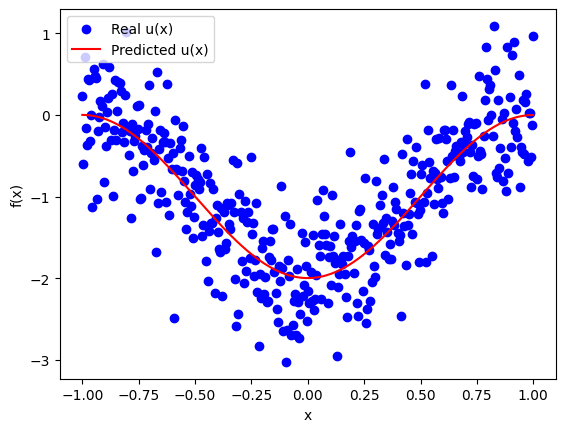

In [3]:
%reset -f
import torch
import torch.nn as nn #Modulo para construção de redes neurais 
import torch.optim as optim #Modulo para implementar os algoritmos de otimização
from torch.utils.data import TensorDataset, DataLoader #Funções para manipulação dos dados 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split #Algoritmos para pré-processamento de dados, compararação de modelos, validação, ...

#Set default dtype to float32
torch.set_default_dtype(torch.float)

#PyTorch random number generator
torch.manual_seed(1234)

# Random number generators in other libraries
np.random.seed(1234)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("device: ",device)

if device == 'cuda': 
    print(torch.cuda.get_device_name())
    


# Função Real / Solução Analítica
def fx(x):
    return -np.cos(np.pi*x)-1

#Função Residual da Equação diferencial
def PDE(x):
    return (np.pi**2)*torch.cos(np.pi*x)

#Função para satisfazer condição de contorno
def BC(x):
    return 1-torch.abs(x)




#Rede Neural
class NN(nn.Module):
    #Inicialização
    def __init__(self,layers):
        super(NN,self).__init__()
        self.LossFcn = nn.MSELoss() #Definir a função custo
        self.activation = nn.Tanh() #Função de Ativação tangente hiperbólica
        self.linears = nn.ModuleList([nn.Linear(layers[i], layers[i+1]) for i in range(len(layers)-1)])
        
    
    #Feed Forward
    def forward(self,x):               
        for i in range(len(layers)-2):  
            x = self.linears[i](x)              
            x = self.activation(x)    
        x = self.linears[-1](x)
        return x
    
    #Funções de perda
    #Função de Perda PDE
    def loss_PDE(self,x_PDE):
        g = x_PDE.clone()
        g.requires_grad = True
        u = self.forward(g)
        u_x = torch.autograd.grad(u,g,torch.ones([x_PDE.shape[0],1]).to(device),retain_graph=True,create_graph=True)[0] #Primeira derivada
        u_xx = torch.autograd.grad(u_x,g,torch.ones([x_PDE.shape[0],1]).to(device),create_graph=True)[0] #Segunda derivada
        return self.LossFcn(u_xx,PDE(g))    
    
    #Função de Perda da condição de contorno
    def loss_BC(self,x_BC,y_BC):
        return self.LossFcn(self.forward(x_BC),y_BC)
    
    #Função de Perda do conjunto de dados
    def loss(self,x_BC,y_BC,x_PDE):
        lossPDE = self.loss_PDE(x_PDE)
        lossBC = self.loss_BC(x_BC,y_BC)
        #lossData = self.LossFcn(Outputs,Targets)
        return lossPDE+lossBC
        
        
        
#Geração dos dados
x = np.linspace(-1,1,400)
y = fx(x)
y = y +np.random.normal(0,0.5,y.shape)

x_BC, y_BC = torch.Tensor([-1,1]).float().view(-1,1), torch.Tensor([0,0]).float().view(-1,1)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.1, random_state=42, shuffle= True)
x_train, y_train = torch.Tensor(x_train).float(), torch.Tensor(y_train).float()
x_test, y_test = torch.Tensor(x_test).float(), torch.Tensor(y_test).float()

layers = np.array([1,10,1])
model = NN(layers)
optimizer = optim.SGD(model.parameters(),lr=0.01, momentum=0.9)
print(model)
    
#Treinamento por Backpropagation
train_dataset = TensorDataset(x_train.view(-1,1),y_train.view(-1,1))
test_dataset = TensorDataset(x_test.view(-1,1),y_test.view(-1,1))

#Treinamento em Mini-batch.
train_loader = DataLoader(train_dataset, batch_size=360, shuffle=False)

num_epochs = 500
losses = [] #Vetor para salvar o comportamento da função custo
model.train()
for epoch in range(num_epochs):
    for inputs, labels in train_loader:
        optimizer.zero_grad() #Zera o gradiente
        #outputs = model(inputs) #Faz o Feedforward e encontra as predições da rede
        loss = model.loss(x_BC,y_BC,inputs)#Calcula o erro (Diferença entre a predição e a saída do dado)
        loss.backward() #Faz a retroprogação do erro e calcula o gradiente em relação a cada parâmetro do modelo
        optimizer.step() #Atualiza os parâmetros(Pesos e vieses) com base no gradiente e a taxa de aprendizado
        if epoch%(num_epochs/20)==0:
            print(loss)
    losses.append(loss.item())

model.eval()
test_loader = DataLoader(test_dataset, batch_size=40, shuffle=False)
with torch.no_grad(): # Disable gradient computation
    for inputs, labels in test_loader:
        outputs = model(inputs) #Faz o Feedforward e encontra as predições da rede
           
# Plot
fig, ax1 = plt.subplots()
ax1.scatter(x,y,color='blue',label='Real u(x)')
ax1.plot(x,model(torch.Tensor(x).float().view(-1,1)).detach().numpy(),color='red',label='Predicted u(x)')
ax1.set_xlabel('x',color='black')
ax1.set_ylabel('f(x)',color='black')
ax1.tick_params(axis='y', color='black')
ax1.legend(loc = 'upper left')      